In [5]:
# Importing Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Read the dataset

df = pd.read_csv(r"E:\US_Batch_AI\ML_End-to-End\ML_project\Dataset\training_dataset\train.csv")

In [4]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [6]:
df.shape

(614, 13)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [8]:
# Decided to change the type of Credit_History to object becaues we can see that it is 1 or 0

df['Credit_History'] = df['Credit_History'].astype('O')

In [9]:
# droping ID because it's not important for our model and it will just mislead the model

df.drop('Loan_ID', axis=1, inplace=True)

In [11]:
df.duplicated().any()
# we got no duplicated rows


False

The percentage of Y class : 0.69
The percentage of N class : 0.31


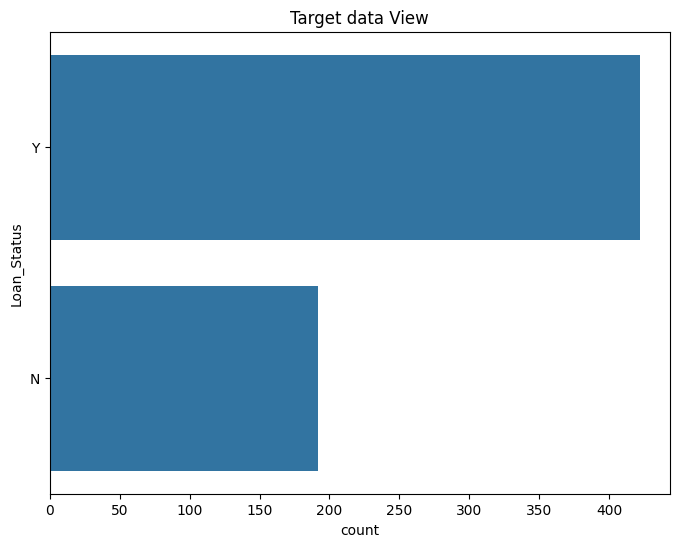

In [17]:
# let's look at the target percentage

plt.figure(figsize=(8,6))
plt.title('Target data View')
sns.countplot(df['Loan_Status'])

print('The percentage of Y class : %.2f' % (df['Loan_Status'].value_counts()[0] / len(df)))
print('The percentage of N class : %.2f' % (df['Loan_Status'].value_counts()[1] / len(df)))

# We can consider it as imbalanced data, but for now i will not

# Saving 

plt.savefig(r"E:\US_Batch_AI\ML_End-to-End\ML_project\Results\EDA_Results/target_distribution_plot.png")


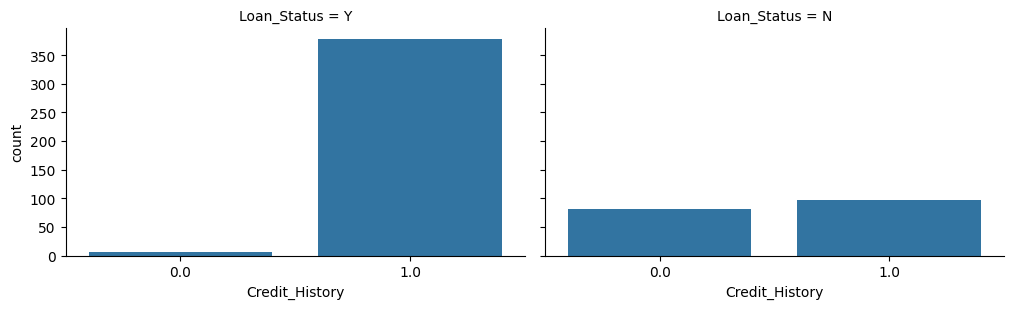

In [19]:
# Credit_History
# Replace 'size' with 'height'
grid = sns.FacetGrid(df, col='Loan_Status', height=3.2, aspect=1.6)  
grid.map(sns.countplot, 'Credit_History')

# we didn't give a loan for most people who got Credit History = 0
# but we did give a loan for most of people who got Credit History = 1
# so we can say if you got Credit History = 1 , you will have better chance to get a loan

# important feature

# Saving 

plt.savefig(r"E:\US_Batch_AI\ML_End-to-End\ML_project\Results\EDA_Results/target_with_credit_history.png")


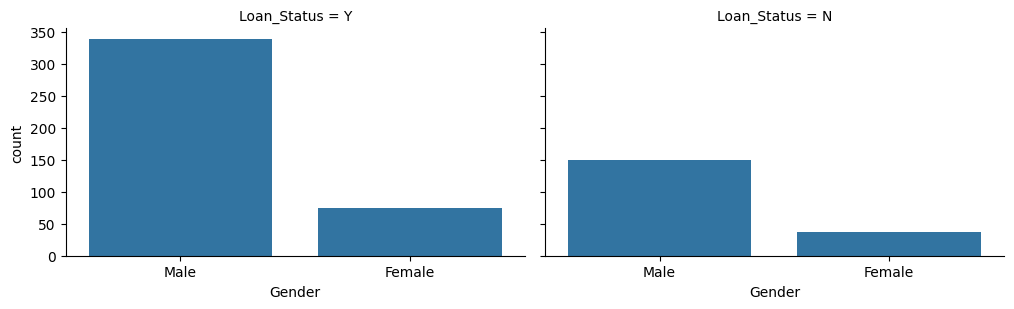

In [20]:
# Gender

grid = sns.FacetGrid(df,col='Loan_Status', height=3.2, aspect=1.6)
grid.map(sns.countplot, 'Gender')

# most males got loan and most females got one too so (No pattern)

# i think it's not so important feature, we will see later

# Saving 

plt.savefig(r"E:\US_Batch_AI\ML_End-to-End\ML_project\Results\EDA_Results/target_with_gender.png")

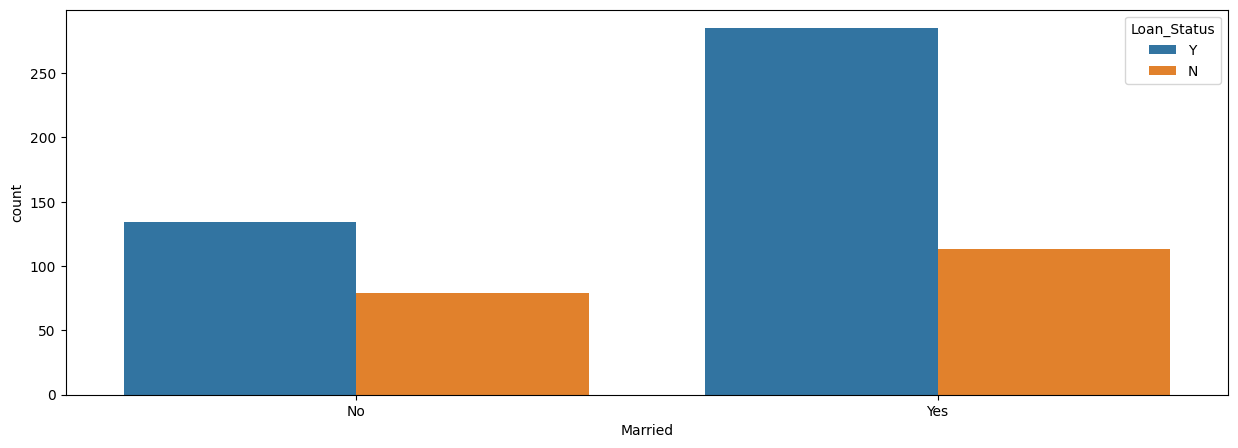

In [21]:
# Married
plt.figure(figsize=(15,5))
sns.countplot(x='Married', hue='Loan_Status', data=df);

# most people who get married did get a loan
# if you'r married then you have better chance to get a loan :)
# good feature

plt.savefig(r"E:\US_Batch_AI\ML_End-to-End\ML_project\Results\EDA_Results/married_status.png")

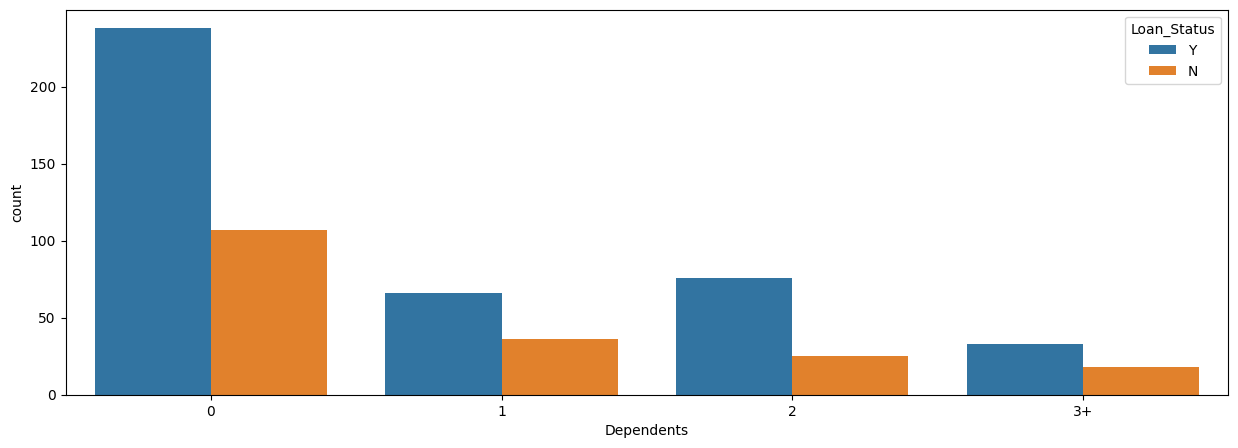

In [22]:
# Dependents

plt.figure(figsize=(15,5))
sns.countplot(x='Dependents', hue='Loan_Status', data=df);

# first if Dependents = 0 , we got higher chance to get a loan ((very hight chance))
# good feature

plt.savefig(r"E:\US_Batch_AI\ML_End-to-End\ML_project\Results\EDA_Results/Dependents.png")

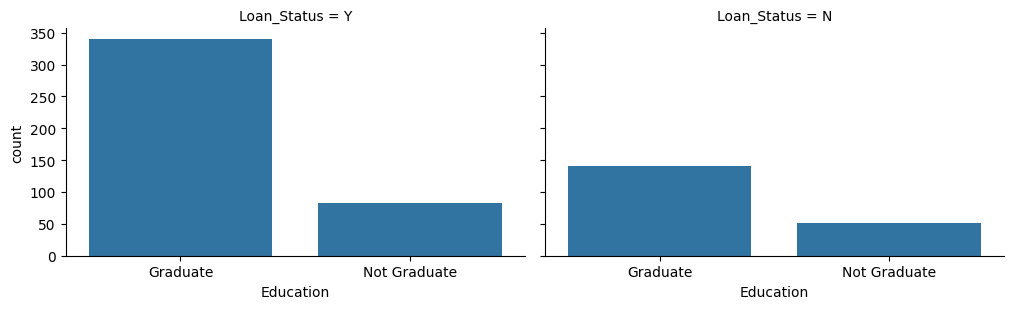

In [23]:
# Education

grid = sns.FacetGrid(df,col='Loan_Status', height=3.2, aspect=1.6)
grid.map(sns.countplot, 'Education');

# If you are graduated or not, you will get almost the same chance to get a loan (No pattern)
# Here you can see that most people did graduated, and most of them got a loan
# on the other hand, most of people who did't graduate also got a loan, but with less percentage from people who graduated

# not important feature
plt.savefig(r"E:\US_Batch_AI\ML_End-to-End\ML_project\Results\EDA_Results/Education.png")

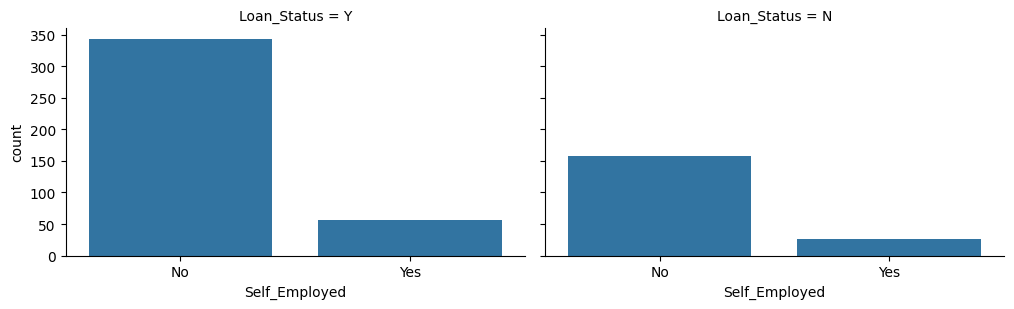

In [24]:
# Self_Employed

grid = sns.FacetGrid(df,col='Loan_Status', height=3.2, aspect=1.6)
grid.map(sns.countplot, 'Self_Employed');

# No pattern (same as Education)
plt.savefig(r"E:\US_Batch_AI\ML_End-to-End\ML_project\Results\EDA_Results/Self_Employed.png")

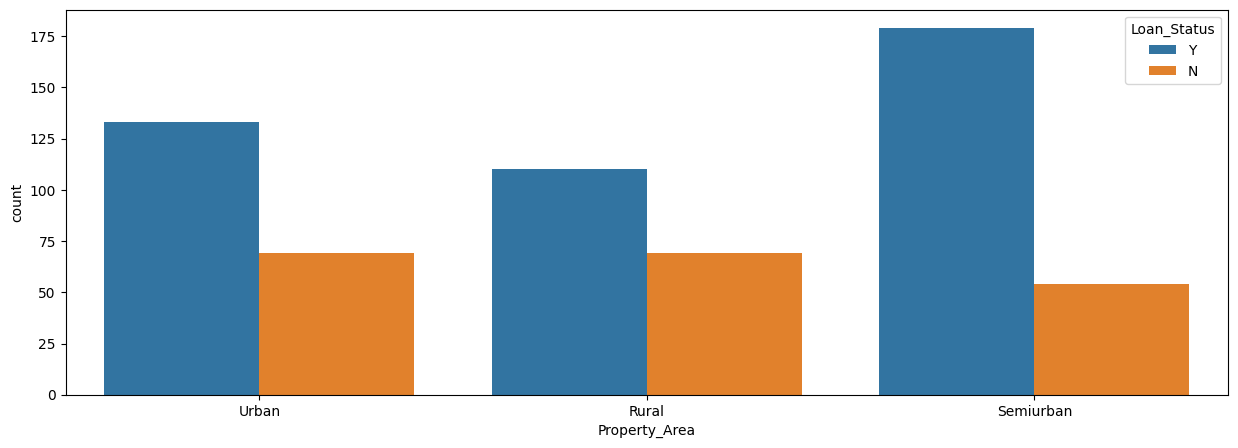

In [25]:
# Property_Area

plt.figure(figsize=(15,5))
sns.countplot(x='Property_Area', hue='Loan_Status', data=df);

# We can say, Semiurban Property_Area got more than 50% chance to get a loan

# good feature


plt.savefig(r"E:\US_Batch_AI\ML_End-to-End\ML_project\Results\EDA_Results/Property_Area.png")

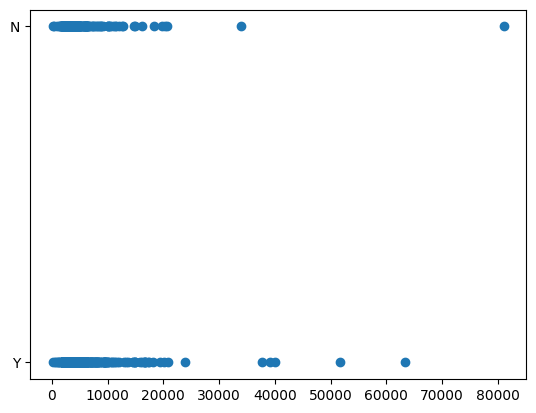

In [26]:
# ApplicantIncome

plt.scatter(df['ApplicantIncome'], df['Loan_Status']);

# No pattern

plt.savefig(r"E:\US_Batch_AI\ML_End-to-End\ML_project\Results\EDA_Results/ApplicantIncome.png")